In [1]:
import os
import optuna
import pandas as pd

model_name = 'UNet_A'
study_id = 1

dataflgs = ['era5', 'noaa']
expflgs = [
    'BEST', 
]
output_vars = ['ROMI', 'RMM']

optuna_dir = "/scratch/users/linyao/ML4MJO/scripts/exp/BEST/optuna"
results = []

print(f"{'Experiment':<60} | {'Trials':<8} | {'Best Value':<12} | {'Best Hyperparameters'}")
print("-" * 120)

for outvar in output_vars:
    for exp in expflgs:
        for dataflg in dataflgs:
            exp_name = f"{dataflg}_{exp}_{model_name}_{outvar}_s{study_id}"
            db_path = os.path.join(optuna_dir, f"{exp_name}.db")
            
            if os.path.exists(db_path):
                try:
                    study = optuna.load_study(study_name=exp_name, storage=f"sqlite:///{db_path}")
                    
                    # Check if there are any completed trials to avoid errors
                    if len([t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]) > 0:
                        best_val = f"{study.best_value:.6f}"
                        best_params = study.best_params # This is the dictionary you want
                    else:
                        best_val = "N/A"
                        best_params = "No completed trials"
                        
                    print(f"{exp_name[:60]:<60} | {len(study.trials):<8} | {best_val:<12} | {best_params}")
                
                except Exception:
                    print(f"{exp_name[:60]:<60} | Error    | Failed to load")
            else:
                print(f"not existing: {exp_name}")
                pass 


/home/users/linyao/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Experiment                                                   | Trials   | Best Value   | Best Hyperparameters
------------------------------------------------------------------------------------------------------------------------
era5_BEST_UNet_A_ROMI_s1                                     | 100      | 0.469046     | {'norm_type': 'batch', 'num_filters_enc': 64, 'kernel_size': 3, 'nhidden1': 256, 'nhidden2': 128, 'nhidden3': 64, 'dropout_rate': 0.4, 'optimizer': 'SGD', 'learning_rate': 0.035012095136311025, 'weight_decay': 4.1316379344078585e-05, 'momentum': 0.8500000000000001, 'batch_size': 48}
noaa_BEST_UNet_A_ROMI_s1                                     | 100      | 0.498432     | {'norm_type': 'batch', 'num_filters_enc': 64, 'kernel_size': 3, 'nhidden1': 512, 'nhidden2': 256, 'nhidden3': 32, 'dropout_rate': 0.30000000000000004, 'optimizer': 'SGD', 'learning_rate': 0.026887576572023893, 'weight_decay': 2.0180162718470344e-05, 'momentum': 0.95, 'batch_size': 48}
era5_BEST_UNet_A_RMM_

In [2]:
import os
import optuna
import pandas as pd
import numpy as np 

model_name = 'UNet_A'
study_id = 1

dataflgs = ['era5', 'noaa']
expflgs = [
    'BEST', 
]
output_vars = ['ROMI', 'RMM']

optuna_dir = "/scratch/users/linyao/ML4MJO/scripts/exp/BEST/optuna"
results = []

print(f"{'Experiment':<60} | {'Trials':<8} | {'Best Value':<12} | {'Best Hyperparameters'}")
print("-" * 120)

for outvar in output_vars:
    for exp in expflgs:
        for dataflg in dataflgs:
            for lead in np.arange(0,40,5):
                exp_name = f"{dataflg}_{exp}_{model_name}_{outvar}_lead{lead}_s{study_id}"
                db_path = os.path.join(optuna_dir, f"{exp_name}.db")
                
                if os.path.exists(db_path):
                    try:
                        study = optuna.load_study(study_name=exp_name, storage=f"sqlite:///{db_path}")
                        
                        # Check if there are any completed trials to avoid errors
                        if len([t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]) > 0:
                            best_val = f"{study.best_value:.6f}"
                            best_params = study.best_params # This is the dictionary you want
                        else:
                            best_val = "N/A"
                            best_params = "No completed trials"
                            
                        print(f"{exp_name[:60]:<60} | {len(study.trials):<8} | {best_val:<12} | {best_params}")
                    
                    except Exception:
                        print(f"{exp_name[:60]:<60} | Error    | Failed to load")
                else:
                    print(f"not existing: {exp_name}")
                    pass 


Experiment                                                   | Trials   | Best Value   | Best Hyperparameters
------------------------------------------------------------------------------------------------------------------------
era5_BEST_UNet_A_ROMI_lead0_s1                               | 100      | 0.154238     | {'norm_type': 'group', 'num_filters_enc': 32, 'kernel_size': 5, 'nhidden1': 512, 'nhidden2': 192, 'nhidden3': 64, 'dropout_rate': 0.1, 'optimizer': 'AdamW', 'learning_rate': 0.0003836683639619545, 'weight_decay': 1.787201214296056e-06, 'batch_size': 16}
era5_BEST_UNet_A_ROMI_lead5_s1                               | 100      | 0.248025     | {'norm_type': 'batch', 'num_filters_enc': 64, 'kernel_size': 7, 'nhidden1': 512, 'nhidden2': 192, 'nhidden3': 16, 'dropout_rate': 0.30000000000000004, 'optimizer': 'SGD', 'learning_rate': 0.0013718288075993254, 'weight_decay': 3.1171315598073666e-05, 'momentum': 0.95, 'batch_size': 48}
era5_BEST_UNet_A_ROMI_lead10_s1                   

--- Hyperparameter Importance for era5_BEST_UNet_A_ROMI_s1 ---
norm_type                : 0.3363 (33.6%)
nhidden1                 : 0.2319 (23.2%)
kernel_size              : 0.1040 (10.4%)
batch_size               : 0.0748 (7.5%)
num_filters_enc          : 0.0586 (5.9%)
optimizer                : 0.0573 (5.7%)
nhidden2                 : 0.0481 (4.8%)
nhidden3                 : 0.0448 (4.5%)
dropout_rate             : 0.0442 (4.4%)


/tmp/ipykernel_192745/995398402.py:21: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  ovm.plot_param_importances(study)


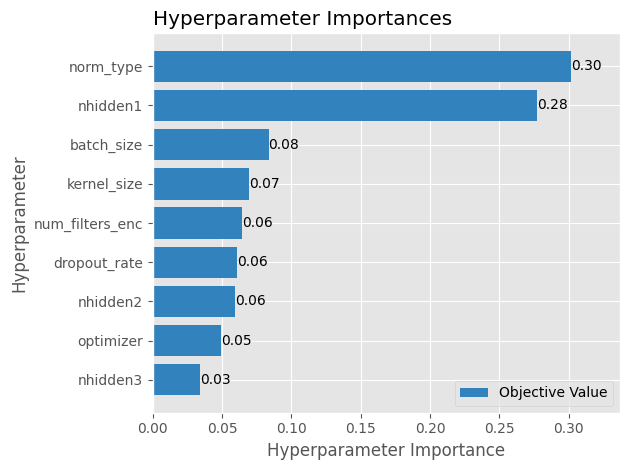

In [3]:
import os
import optuna
import matplotlib.pyplot as plt
import optuna.visualization.matplotlib as ovm

exp_name = "era5_BEST_UNet_A_ROMI_s1"
storage = f"sqlite:////scratch/users/linyao/ML4MJO/scripts/exp/BEST/optuna/{exp_name}.db"

# 1. Load Study
study = optuna.load_study(study_name=exp_name, storage=storage)

# 2. Corrected Function Name: get_param_importances (with an 's')
importance = optuna.importance.get_param_importances(study)

print(f"--- Hyperparameter Importance for {exp_name} ---")
for param, val in importance.items():
    print(f"{param:<25}: {val:.4f} ({val*100:.1f}%)")

# 3. Matplotlib-based Plots (to avoid Plotly requirement)
# Importance Plot
ovm.plot_param_importances(study)
# plt.title(f"Importance: {exp_name}")
plt.tight_layout()
plt.show()

